In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/PrathmeshPawale89/my-website/refs/heads/main/StudentsPerformance.csv"
df = pd.read_csv(url)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Missing Values:\n", df.isnull().sum())

print("\nUnique values check:")
for col in df.columns:
    print(col, ":", df[col].unique()[:5])

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Unique values check:
gender : ['female' 'male']
race/ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school']
lunch : ['standard' 'free/reduced']
test preparation course : ['none' 'completed']
math score : [72 69 90 47 76]
reading score : [72 90 95 57 78]
writing score : [74 88 93 44 75]


In [5]:
# Fill numeric columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with mode (FIXED)
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

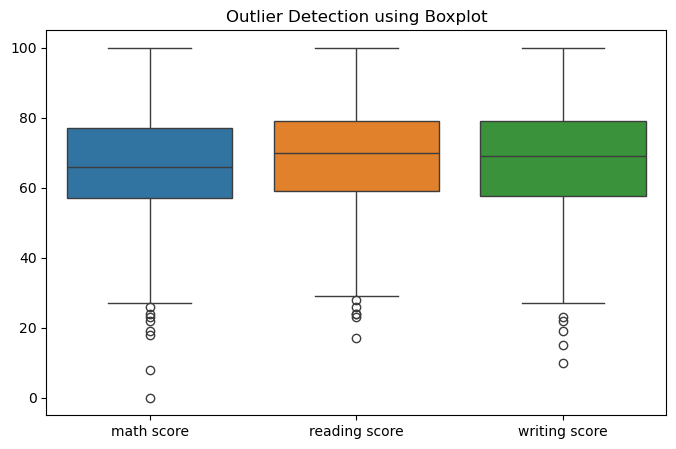

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math score','reading score','writing score']])
plt.title("Outlier Detection using Boxplot")
plt.show()

In [7]:
Q1 = df[['math score','reading score','writing score']].quantile(0.25)
Q3 = df[['math score','reading score','writing score']].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[['math score','reading score','writing score']] < (Q1 - 1.5 * IQR)) |
                (df[['math score','reading score','writing score']] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (1000, 8)
After removing outliers: (988, 8)


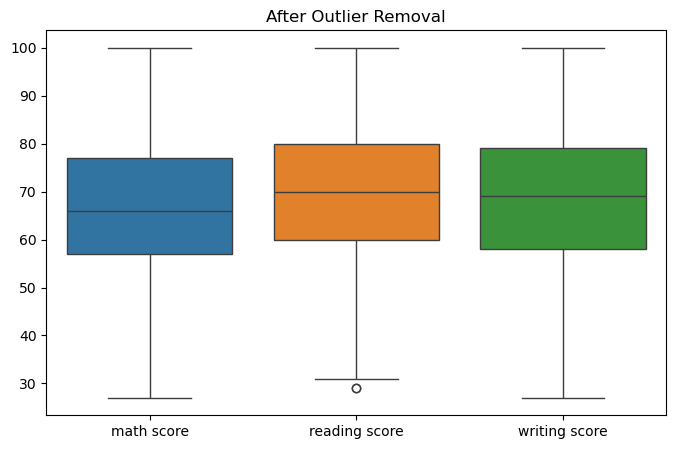

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean[['math score','reading score','writing score']])
plt.title("After Outlier Removal")
plt.show()

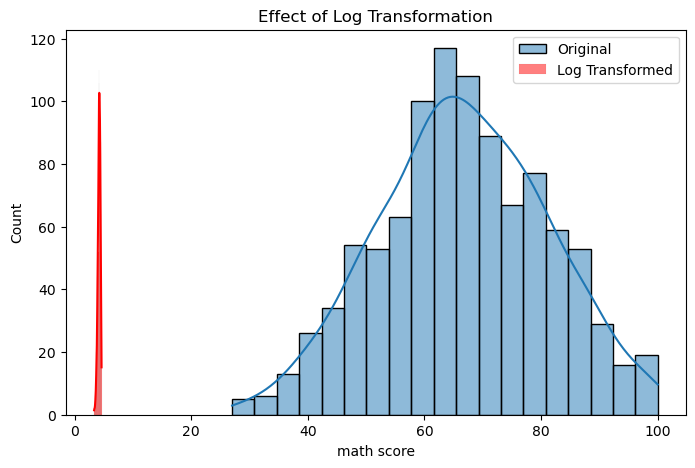

In [10]:
# Make explicit copy to avoid warning
df_clean = df_clean.copy()

# Apply transformation safely
df_clean.loc[:, 'math_log'] = np.log1p(df_clean['math score'])

plt.figure(figsize=(8,5))
sns.histplot(df_clean['math score'], kde=True, label="Original")
sns.histplot(df_clean['math_log'], kde=True, color='red', label="Log Transformed")
plt.legend()
plt.title("Effect of Log Transformation")
plt.show()

In [11]:
print("Data Wrangling II completed:")
print("✔ Missing values handled")
print("✔ Outliers detected and removed")
print("✔ Data transformation applied")

Data Wrangling II completed:
✔ Missing values handled
✔ Outliers detected and removed
✔ Data transformation applied
